# What can €1,000 of retail capital actually do?

Sixth and final notebook. The constraint changes the question, so the analysis
has to change with it — and not in the direction that helps.

## What the previous five established

| | verdict | why |
|---|---|---|
| Passive holding | NO | BTC +5.7%/yr at Sharpe 0.10 since 2021; alt basket lost money |
| Cross-sectional fundamentals | NO | real signal, but capacity ~\$250k |
| Trend-following | NO (as alpha) | fails walk-forward; 7% of rules beat buy-and-hold OOS |

## What €1,000 changes

**One constraint relaxes.** Capacity killed the fundamentals signal at
institutional size. At €1,000 market impact is essentially zero — clips are
€60–200 against names with tens of thousands of dollars of depth. The
$250k ceiling is irrelevant to you.

**Three constraints bind much harder, and they are new:**

1. **No shorting.** The fundamentals alpha lives in non-perp names. By
   definition those have no perpetual future, EU retail access to offshore perp
   venues is restricted under MiCA anyway, and spot borrow for altcoins does not
   exist at retail. So the only executable structure is **long-only**, which
   notebook 4 already measured at t = 1.04 — insignificant.
2. **CEX-only execution.** Roughly 40% of the names carrying the alpha trade on
   no retail exchange at all — they are DEX-only. Trading those means on-chain
   swaps, and at a €60–125 position size Ethereum gas alone is 2–30% *per
   trade*. Fixed costs, not proportional ones, are the binding constraint at
   this size.
3. **Fixed costs dominate.** Everything in notebooks 2–4 charged proportional
   cost. At €1,000 the euro amounts are small enough that per-trade minimums,
   spreads and (if on-chain) gas swamp them.

## The question this notebook answers

Restricted to **what a European retail account can actually buy**, **long-only**,
at **€1,000**, with **realistic retail fees** — is there anything here worth
doing? And the question that matters more at this size: **is any of it worth the
hours?**

In [1]:
from __future__ import annotations

import glob, gzip, json, os, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = REPO / "data" / "crypto_panel"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


CAPITAL_EUR = 1_000.0
DESIGN_END = pd.Timestamp("2025-03-01")
BACKTEST_START = pd.Timestamp("2021-06-01")
REBAL_D = 30
FEE_PCT_PER_SIDE = 0.0025      # Kraken / Bitvavo taker; swept later
MIN_ORDER_EUR = 10.0

## 1. Panel and retail-accessible universe

Same committed panel as notebooks 2–5. The new ingredient is **venue
availability**: CoinGecko's `/tickers` response names every exchange quoting
each token, so tokens can be classified by whether a European retail account
could actually buy them.

* **Tier 1** — Binance, Coinbase, Kraken, Bitstamp, Bitvavo, Bitpanda. What a
  European retail user can open in an afternoon with a bank transfer.
* **Any retail CEX** — adds KuCoin, OKX, Bybit, Gate.io. Reachable, but with
  more friction and, post-MiCA, more uncertainty for EU residents.
* **DEX-only** — no retail CEX at all. Executable only via on-chain swaps.

The listings are a **current** snapshot applied across history. That is
look-ahead, and it biases *in favour* of the strategy: a token listed on Kraken
today may not have been in 2022. So the results below are an upper bound.

In [2]:
PX_RAW = pd.read_csv(PANEL / "prices.csv.gz", index_col=0, parse_dates=True)
FEES = pd.read_csv(PANEL / "fees.csv.gz", index_col=0, parse_dates=True)
BENCH = pd.read_csv(PANEL / "benchmarks.csv.gz", index_col=0, parse_dates=True)

CAL = pd.date_range(PX_RAW.index.min(), PX_RAW.index.max(), freq="D")
PX_RAW, FEES = PX_RAW.reindex(CAL), FEES.reindex(CAL).fillna(0.0)
lp = np.log(PX_RAW.where(PX_RAW > 0))
d1, d2 = lp.diff(), lp.diff().shift(-1)
bad = (d1.abs() > 1.5) & (d2.abs() > 1.5) & (np.sign(d1) != np.sign(d2))
PX = PX_RAW.where(PX_RAW > 0).mask(bad)
PX = PX.where(~bad, np.exp((np.log(PX).ffill() + np.log(PX).bfill()) / 2))
PX = PX.ffill(limit=3).where(PX.bfill().notna())
first_fee = FEES.where(FEES > 0).apply(lambda c: c.first_valid_index())
for c in PX.columns:
    ff = first_fee.get(c)
    if pd.notna(ff):
        PX.loc[: ff - pd.Timedelta(days=365), c] = np.nan

FEES_90 = FEES.rolling(90, min_periods=60).sum()
ELIGIBLE = ((FEES_90 >= 1e6)
            & (PX.notna().rolling(180, min_periods=180).count() >= 180) & PX.notna())
BTC = BENCH["bitcoin"].dropna()

TIER1 = {"binance", "coinbase exchange", "kraken", "bitstamp", "bitvavo", "bitpanda"}
RETAIL = TIER1 | {"crypto.com exchange", "kucoin", "okx", "bybit", "gate.io"}

# Built by experiments/build_venue_table.py from the cached /tickers responses
# and committed, so this notebook runs offline like the rest of the sequence.
VEN = pd.read_csv(PANEL / "venues.csv").set_index("gecko_id")

for name, col in (("tier-1 EU venue", "tier1"), ("any retail CEX", "retail")):
    ids = VEN.index[VEN[col]]
    mask = ELIGIBLE.copy()
    mask[[c for c in mask.columns if c not in ids]] = False
    globals()["U_" + col.upper()] = mask
    print(f"{name:18s}: {int(VEN[col].sum()):3d} of {len(VEN)} tokens with venue data; "
          f"mean eligible breadth {mask.loc[BACKTEST_START:].sum(axis=1).mean():5.1f} "
          f"(vs {ELIGIBLE.loc[BACKTEST_START:].sum(axis=1).mean():.1f} unrestricted)")
print(f"\nmedian bid-ask spread on tier-1 venues: {VEN.spread_pct.median():.3f}%")

tier-1 EU venue   : 125 of 200 tokens with venue data; mean eligible breadth  53.8 (vs 73.7 unrestricted)
any retail CEX    : 138 of 200 tokens with venue data; mean eligible breadth  57.3 (vs 73.7 unrestricted)

median bid-ask spread on tier-1 venues: 0.153%


### 1.1 The structural problem, in one table

Before any backtest, it is worth checking whether the retail-accessible
universe and the universe where the signal lives are even the same set.

Notebook 4 measured where the edge exists: present in names with five-figure
order-book depth, **gone above roughly \$250k of 2% depth**. So the question
is simply whether a European retail account can buy the thin names.

In [3]:
perp = pd.read_csv(PANEL / "perp_listings.csv").set_index("gecko_id")
S = VEN.dropna(subset=["depth_2pct_usd"]).copy()
S = S[S.depth_2pct_usd > 0]
S["has_perp"] = perp["perp_listed"].notna().reindex(S.index).fillna(False)

ct = pd.crosstab(S.tier1, S.has_perp)
ct.index = ["NOT retail-buyable", "retail-buyable (tier-1)"]
ct.columns = ["not shortable", "shortable (has perp)"]
print("Retail-buyable versus shortable\n")
print(ct.to_string())

print(f"\nMedian 2% order-book depth:")
print(f"  retail-buyable (tier-1)  ${S[S.tier1].depth_2pct_usd.median():>13,.0f}")
print(f"  NOT retail-buyable       ${S[~S.tier1].depth_2pct_usd.median():>13,.0f}")
print(f"  ratio                     {S[S.tier1].depth_2pct_usd.median()/S[~S.tier1].depth_2pct_usd.median():>13,.0f}x")

above = 250_000
print(f"\nShare above ${above:,} of depth - the level at which notebook 4 found the edge gone:")
print(f"  retail-buyable (tier-1)  {(S[S.tier1].depth_2pct_usd > above).mean()*100:>5.0f}%")
print(f"  NOT retail-buyable       {(S[~S.tier1].depth_2pct_usd > above).mean()*100:>5.0f}%")
print(f"""
  That is the whole problem stated without a backtest. The names a European
  retail account can buy are ~{S[S.tier1].depth_2pct_usd.median()/S[~S.tier1].depth_2pct_usd.median():,.0f}x deeper than the ones it cannot, and {(S[S.tier1].depth_2pct_usd > above).mean()*100:.0f}% of them
  sit above the depth at which the signal stops working - against {(S[~S.tier1].depth_2pct_usd > above).mean()*100:.0f}% of the
  names off-limits to retail.

  The retail-accessible universe is close to the exact complement of the
  universe where the alpha lives. Everything below is confirmation.""")

Retail-buyable versus shortable

                         not shortable  shortable (has perp)
NOT retail-buyable                  50                     4
retail-buyable (tier-1)             46                    79

Median 2% order-book depth:
  retail-buyable (tier-1)  $    2,366,728
  NOT retail-buyable       $        4,971
  ratio                               476x

Share above $250,000 of depth - the level at which notebook 4 found the edge gone:
  retail-buyable (tier-1)     78%
  NOT retail-buyable           2%

  That is the whole problem stated without a backtest. The names a European
  retail account can buy are ~476x deeper than the ones it cannot, and 78% of them
  sit above the depth at which the signal stops working - against 2% of the
  names off-limits to retail.

  The retail-accessible universe is close to the exact complement of the
  universe where the alpha lives. Everything below is confirmation.


## 2. Retail cost model

Notebooks 2–4 charged a proportional cost and, at the end, a market-impact
model. Neither is the right model at €1,000. Here the cost of a trade is:

$$\text{cost} = \underbrace{\text{exchange fee}}_{0.25\%\ \text{taker}} + \underbrace{\tfrac{1}{2}\,\text{spread}}_{\text{measured, per token}}$$

with **no market-impact term at all** — a €100 clip against a book with tens of
thousands of dollars of depth moves nothing. That is the one place the small
account is genuinely advantaged, and the model reflects it.

Fees are Kraken/Bitvavo taker rates (0.25%); Binance is cheaper (0.10%),
Coinbase dearer (0.60%). The sweep covers all three. Spreads are the measured
median across tier-1 venues, per token.

In [4]:
def zs(df, universe):
    return (df.where(universe).rank(axis=1, pct=True) - 0.5) * np.sqrt(12)


def signals(universe):
    f = FEES.rolling(90, min_periods=63).sum().replace(0, np.nan)
    fee_growth = f / f.shift(90) - 1
    value_gap = (PX / PX.shift(90) - 1) - fee_growth
    return (zs(value_gap, universe) + zs(-fee_growth, universe)) / 2


SPREAD = VEN.spread_pct.reindex(PX.columns).fillna(VEN.spread_pct.median()) / 100.0


def long_only(universe, n_hold=10, fee_pct=FEE_PCT_PER_SIDE, horizon=REBAL_D,
              start=BACKTEST_START, end=None, use_signal=True, capital=CAPITAL_EUR):
    """Buy the n_hold cheapest names in `universe`, equal weight, monthly.
    Returns per-period net returns plus the benchmark (equal-weight universe)."""
    sig = signals(universe)
    fwd = PX.shift(-horizon) / PX - 1.0
    dates = CAL[CAL >= start][::horizon]
    dates = dates[dates < end] if end is not None else dates
    recs, W = [], []
    for d in dates:
        avail = universe.loc[d]
        names = avail[avail].index
        r = fwd.loc[d, names].dropna()
        if len(r) < max(8, n_hold + 3):
            continue
        r = r.clip(r.quantile(0.01), r.quantile(0.99))
        if use_signal:
            s = sig.loc[d, r.index].replace([np.inf, -np.inf], np.nan).dropna()
            if len(s) < max(8, n_hold + 3):
                continue
            picks = s.nsmallest(n_hold).index
        else:
            picks = r.index
        w = pd.Series(0.0, index=PX.columns)
        w[picks] = 1.0 / len(picks)
        recs.append({"date": d, "port": float(r[picks].mean()), "bench": float(r.mean()),
                     "n": len(picks), "pos_eur": capital / len(picks)})
        W.append(w)
    if len(recs) < 6:
        return None
    df = pd.DataFrame(recs).set_index("date")
    Wm = pd.DataFrame(W, index=df.index).fillna(0.0)
    trade = Wm.diff().abs().fillna(Wm.abs())
    cost_rate = fee_pct + SPREAD.reindex(Wm.columns).fillna(SPREAD.median()) / 2
    cost = (trade * cost_rate).sum(axis=1)
    net = df["port"] - cost
    return {"n_periods": len(df), "gross_%": df["port"].mean() * 100,
            "bench_%": df["bench"].mean() * 100, "cost_bps": cost.mean() * 1e4,
            "net_%": net.mean() * 100, "excess_%": (net - df["bench"]).mean() * 100,
            "t_excess": ((net - df["bench"]).mean()
                         / ((net - df["bench"]).std(ddof=1) / np.sqrt(len(df)))),
            "turnover": float(trade.sum(axis=1).mean()),
            "pos_eur": df["pos_eur"].iloc[0], "net": net, "bench": df["bench"]}


print(f"RETAIL LONG-ONLY, €{CAPITAL_EUR:,.0f}, tier-1 EU venues only\n")
rows = []
for n_hold in (5, 8, 10, 15):
    for lbl, kw in (("design", dict(end=DESIGN_END)), ("holdout", dict(start=DESIGN_END))):
        r = long_only(U_TIER1, n_hold=n_hold, **kw)
        if r:
            rows.append({"n_hold": n_hold, "period": lbl, "pos_eur": r["pos_eur"],
                         **{k: v for k, v in r.items()
                            if k in ("n_periods", "gross_%", "bench_%", "cost_bps",
                                     "net_%", "excess_%", "t_excess", "turnover")}})
RET = pd.DataFrame(rows)
print(RET.round(2).to_string(index=False))
print(f"""
  'excess_%' is net-of-cost return minus the equal-weight retail universe - the
  honest measure of whether the signal added anything a coin-flip portfolio of the
  same tokens would not have given you.""")

RETAIL LONG-ONLY, €1,000, tier-1 EU venues only



 n_hold  period  pos_eur  n_periods  gross_%  bench_%  cost_bps  net_%  excess_%  t_excess  turnover
      5  design  200.000         46    5.570    2.910    38.470  5.180     2.270     0.830     1.000
      5 holdout  200.000         18   -3.880   -2.810    35.660 -4.240    -1.430    -0.610     0.990
      8  design  125.000         46    4.000    2.910    32.420  3.680     0.770     0.460     0.850
      8 holdout  125.000         18   -2.150   -2.810    32.610 -2.470     0.340     0.200     0.880
     10  design  100.000         46    4.140    2.910    30.830  3.830     0.920     0.600     0.790
     10 holdout  100.000         18   -2.740   -2.810    29.840 -3.040    -0.230    -0.160     0.810
     15  design   66.670         44    4.410    2.950    26.270  4.150     1.200     0.960     0.670
     15 holdout   66.670         18   -2.570   -2.810    31.480 -2.890    -0.080    -0.060     0.780

  'excess_%' is net-of-cost return minus the equal-weight retail universe - the
  honest m

## 3. Fee sensitivity — does the venue choice decide it?

Binance 0.10%, Kraken/Bitvavo 0.25%, Coinbase 0.60%. If the answer flips
across that range, the answer is really about fee tiers, not about the signal.

In [5]:
rows = []
for fee, venue in ((0.0010, "Binance 0.10%"), (0.0025, "Kraken/Bitvavo 0.25%"),
                   (0.0040, "Kraken low-tier 0.40%"), (0.0060, "Coinbase 0.60%")):
    for lbl, kw in (("design", dict(end=DESIGN_END)), ("holdout", dict(start=DESIGN_END))):
        r = long_only(U_TIER1, n_hold=10, fee_pct=fee, **kw)
        if r:
            rows.append({"venue": venue, "period": lbl, "cost_bps": r["cost_bps"],
                         "net_%": r["net_%"], "excess_%": r["excess_%"], "t": r["t_excess"]})
FEESENS = pd.DataFrame(rows)
print(FEESENS.round(2).to_string(index=False))

                venue  period  cost_bps  net_%  excess_%      t
        Binance 0.10%  design    19.030  3.950     1.040  0.670
        Binance 0.10% holdout    17.680 -2.920    -0.110 -0.080
 Kraken/Bitvavo 0.25%  design    30.830  3.830     0.920  0.600
 Kraken/Bitvavo 0.25% holdout    29.840 -3.040    -0.230 -0.160
Kraken low-tier 0.40%  design    42.640  3.720     0.810  0.520
Kraken low-tier 0.40% holdout    42.010 -3.160    -0.350 -0.250
       Coinbase 0.60%  design    58.380  3.560     0.650  0.420
       Coinbase 0.60% holdout    58.230 -3.330    -0.520 -0.360


## 4. The benchmarks that actually matter at this size

A €1,000 account has alternatives that cost nothing to run. Any strategy has to
beat *those*, not just beat zero. Trend on BTC is included at retail fees, since
notebook 5 showed it is the one thing with a durable drawdown benefit.

In [6]:
def compound(per_period: pd.Series) -> float:
    return float((1 + per_period).prod())


def sma_trend_eur(px: pd.Series, lb: int, fee_pct: float, start, end=None):
    p = px.loc[start:end] if end is not None else px.loc[start:]
    sma = px.rolling(lb).mean().reindex(p.index)
    pos = (p > sma).astype(float).shift(1).fillna(0.0)
    r = p.pct_change().fillna(0.0)
    switch = pos.diff().abs().fillna(0.0)
    net = r * pos - switch * fee_pct
    return float((1 + net).prod()), float(net.std() * np.sqrt(365)), \
        float(((1 + net).cumprod() / (1 + net).cumprod().cummax() - 1).min())


etf = pd.read_csv(REPO / "datasets" / "etf_universe_prices.csv.gz",
                  usecols=["Date", "SPY"], parse_dates=["Date"]).set_index("Date")["SPY"].dropna()

rows = []
for lbl, lo, hi in (("design 2021-06..2025-02", BACKTEST_START, DESIGN_END),
                    ("holdout 2025-03..2026-09", DESIGN_END, None)):
    tilt = long_only(U_TIER1, n_hold=10, start=lo, end=hi)
    if tilt is None:
        continue
    yrs = ((hi or CAL[-1]) - lo).days / 365.25
    btc_seg = BTC.loc[lo:hi] if hi is not None else BTC.loc[lo:]
    spy_seg = etf.loc[lo:hi] if hi is not None else etf.loc[lo:]
    tr_mult, _, tr_dd = sma_trend_eur(BTC, 200, FEE_PCT_PER_SIDE, lo, hi)
    entries = [
        ("Fundamentals tilt (10 names, monthly)", compound(tilt["net"])),
        ("Equal-weight retail crypto basket", compound(tilt["bench"])),
        ("BTC buy & hold", float(btc_seg.iloc[-1] / btc_seg.iloc[0])),
        ("BTC 200d trend filter", tr_mult),
        ("SPY buy & hold", float(spy_seg.iloc[-1] / spy_seg.iloc[0]) if len(spy_seg) > 20 else np.nan),
    ]
    for name, mult in entries:
        rows.append({"period": lbl, "strategy": name, "years": yrs,
                     "€1,000 becomes": CAPITAL_EUR * mult if np.isfinite(mult) else np.nan,
                     "profit_eur": CAPITAL_EUR * (mult - 1) if np.isfinite(mult) else np.nan,
                     "per_year_eur": CAPITAL_EUR * (mult - 1) / yrs if np.isfinite(mult) else np.nan})
EUR = pd.DataFrame(rows)
print(f"WHAT €{CAPITAL_EUR:,.0f} ACTUALLY BECOMES\n")
for lbl in EUR.period.unique():
    sub = EUR[EUR.period == lbl].set_index("strategy")
    print(f"  {lbl}  ({sub.years.iloc[0]:.1f} years)")
    print(sub[["€1,000 becomes", "profit_eur", "per_year_eur"]].round(0).to_string())
    print()

WHAT €1,000 ACTUALLY BECOMES

  design 2021-06..2025-02  (3.7 years)
                                       €1,000 becomes  profit_eur  per_year_eur
strategy                                                                       
Fundamentals tilt (10 names, monthly)       1,362.000     362.000        97.000
Equal-weight retail crypto basket             868.000    -132.000       -35.000
BTC buy & hold                              2,154.000   1,154.000       308.000
BTC 200d trend filter                       1,307.000     307.000        82.000
SPY buy & hold                              1,494.000     494.000       132.000

  holdout 2025-03..2026-09  (1.5 years)
                                       €1,000 becomes  profit_eur  per_year_eur
strategy                                                                       
Fundamentals tilt (10 names, monthly)         469.000    -531.000      -350.000
Equal-weight retail crypto basket             482.000    -518.000      -341.000
BTC buy & 

## 5. The calculation nobody runs

At €1,000 the interesting number is not Sharpe. It is euros per hour.

In [7]:
hold_tilt = long_only(U_TIER1, n_hold=10, start=DESIGN_END)
n_names = 10
rebalances_per_year = 365 / REBAL_D
trades_per_year = rebalances_per_year * n_names * hold_tilt["turnover"]
hours = (trades_per_year * 2 / 60) + 12 * 1.0     # ~2 min/trade + 1 hr/month upkeep
excess_eur_yr = CAPITAL_EUR * hold_tilt["excess_%"] / 100 * rebalances_per_year

print(f"""  Running the tilt at €{CAPITAL_EUR:,.0f}:

    positions                      {n_names}  (€{CAPITAL_EUR/n_names:,.0f} each)
    rebalances per year            {rebalances_per_year:.0f}
    trades per year                {trades_per_year:.0f}
    realistic hours per year       {hours:.0f}   (2 min/trade + 1 hr/month upkeep)
    taxable disposals per year     {trades_per_year:.0f}   (each one reportable in most EU regimes)

    holdout excess over the basket {hold_tilt['excess_%']:+.2f}%/30d  (t = {hold_tilt['t_excess']:+.2f})
    that is                        €{excess_eur_yr:+,.0f} per year
    per hour of your time          €{excess_eur_yr/hours:+,.1f}
""")

  Running the tilt at €1,000:

    positions                      10  (€100 each)
    rebalances per year            12
    trades per year                99
    realistic hours per year       15   (2 min/trade + 1 hr/month upkeep)
    taxable disposals per year     99   (each one reportable in most EU regimes)

    holdout excess over the basket -0.23%/30d  (t = -0.16)
    that is                        €-28 per year
    per hour of your time          €-1.9



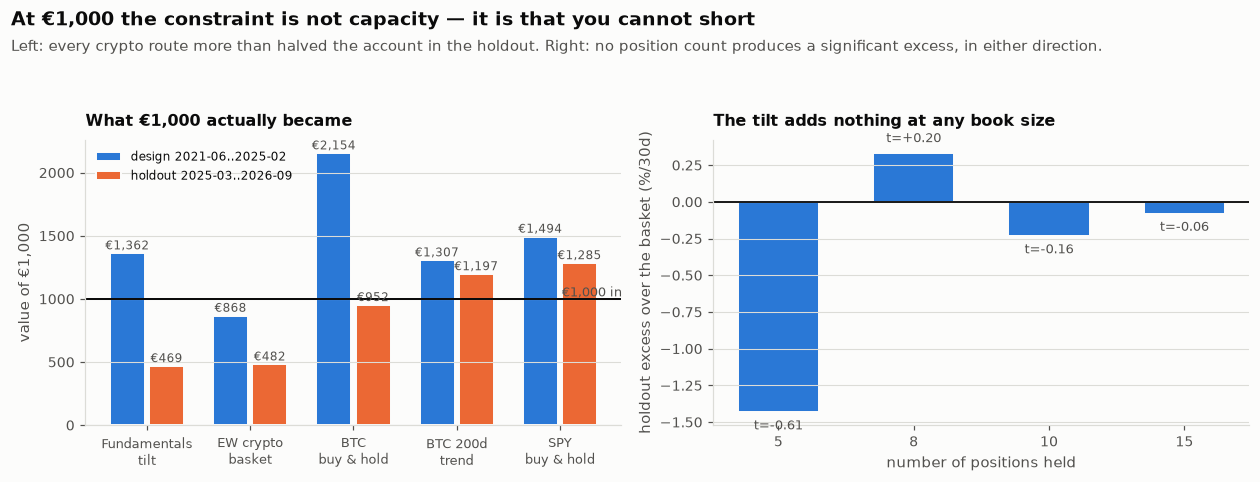

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
hold = EUR[EUR.period.str.startswith("holdout")].set_index("strategy")
des = EUR[EUR.period.str.startswith("design")].set_index("strategy")
order = ["Fundamentals tilt (10 names, monthly)", "Equal-weight retail crypto basket",
         "BTC buy & hold", "BTC 200d trend filter", "SPY buy & hold"]
short = ["Fundamentals\ntilt", "EW crypto\nbasket", "BTC\nbuy & hold", "BTC 200d\ntrend", "SPY\nbuy & hold"]
x = np.arange(len(order))
b1 = axes[0].bar(x - 0.19, des.reindex(order)["€1,000 becomes"], 0.34, color=C1,
                 label="design 2021-06..2025-02", edgecolor=SURFACE, linewidth=1.3)
b2 = axes[0].bar(x + 0.19, hold.reindex(order)["€1,000 becomes"], 0.34, color=C2,
                 label="holdout 2025-03..2026-09", edgecolor=SURFACE, linewidth=1.3)
axes[0].axhline(CAPITAL_EUR, color=INK, lw=1.3)
axes[0].text(len(order) - 0.4, CAPITAL_EUR * 1.02, "€1,000 in", fontsize=8.5, color=INK_2, ha="right")
for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        if np.isfinite(v):
            axes[0].text(bar.get_x() + bar.get_width() / 2, v + 30, f"€{v:,.0f}",
                         ha="center", fontsize=8, color=INK_2)
axes[0].set_xticks(x, short, fontsize=8.5)
axes[0].set_ylabel("value of €1,000")
axes[0].set_title("What €1,000 actually became")
axes[0].legend(loc="upper left", fontsize=8); axes[0].grid(axis="x", visible=False)

sub = RET[RET.period == "holdout"]
axes[1].bar(sub.n_hold.astype(str), sub["excess_%"], color=C1, width=0.6,
            edgecolor=SURFACE, linewidth=1.3)
axes[1].axhline(0, color=INK, lw=1.2)
for xi, (e, t) in enumerate(zip(sub["excess_%"], sub["t_excess"])):
    axes[1].text(xi, e + (0.05 if e >= 0 else -0.05), f"t={t:+.2f}", ha="center",
                 va="bottom" if e >= 0 else "top", fontsize=8.5, color=INK_2)
axes[1].set_xlabel("number of positions held")
axes[1].set_ylabel("holdout excess over the basket (%/30d)")
axes[1].set_title("The tilt adds nothing at any book size")
axes[1].grid(axis="x", visible=False)
figure_titles(fig, "At €1,000 the constraint is not capacity — it is that you cannot short",
              "Left: every crypto route more than halved the account in the holdout. Right: no position count produces a significant excess, in either direction.")
plt.show()

---
# VERDICT

In [9]:
W = 80
h10 = RET[(RET.n_hold == 10) & (RET.period == "holdout")].iloc[0]
d10 = RET[(RET.n_hold == 10) & (RET.period == "design")].iloc[0]
print("=" * W)
print("NO — AND THE €1,000 CONSTRAINT MAKES IT WORSE, NOT BETTER".center(W))
print("=" * W)
print(f"""
THE ONE THING THAT GOT EASIER DOES NOT HELP
{'-'*W}
  Capacity was what killed the fundamentals signal at institutional size: ~$250k
  before market impact ate the edge. At €1,000 impact is nil - your clips are
  €100 against books with tens of thousands of dollars of depth. Cost per
  rebalance falls to {h10.cost_bps:.0f}bp, almost all of it exchange fee and spread.

  It does not matter, because the alpha was never in the long leg. Notebook 4
  located it in names with no perpetual future - which is exactly the set you
  cannot short at retail, at any size. Removing the short leg removes the signal,
  and no amount of small-account nimbleness brings it back.

WHAT THE EXECUTABLE VERSION ACTUALLY DID
{'-'*W}
  Long-only, 10 names, tier-1 EU venues, monthly, 0.25% taker:

    design   excess over the equal-weight basket {d10['excess_%']:+.2f}%/30d  (t = {d10['t_excess']:+.2f})
    holdout  excess over the equal-weight basket {h10['excess_%']:+.2f}%/30d  (t = {h10['t_excess']:+.2f})

  Insignificant in both, and negative out of sample. Worse, the excess is measured
  against a benchmark that fell hard: in the holdout the tilt turned €1,000 into
  €{hold.loc['Fundamentals tilt (10 names, monthly)','€1,000 becomes']:,.0f} while simply owning the whole retail universe equal-weighted
  gave €{hold.loc['Equal-weight retail crypto basket','€1,000 becomes']:,.0f}. The signal did not even earn its trading costs, and outperforming
  a falling universe would only be worth money if you could short it - which you
  cannot.

THE NUMBER THAT SETTLES IT
{'-'*W}
  The holdout excess is €{excess_eur_yr:+,.0f} per year, for {hours:.0f} hours of work and {trades_per_year:.0f} taxable
  disposals - €{excess_eur_yr/hours:+,.1f} per hour, before tax. Even the design period, where the
  signal looked best, paid only €{CAPITAL_EUR * d10['excess_%'] / 100 * rebalances_per_year:+,.0f}/yr for the same effort, at t = {d10['t_excess']:.2f}.

  In most EU regimes each of those {trades_per_year:.0f} disposals is separately reportable.
  The bookkeeping alone costs more than the edge.
""")
print("=" * W)
print("WHAT IS WORTH TESTING AT THIS SIZE (AND WHAT IS NOT)")
print("=" * W)
print(f"""  NOT WORTH TESTING with €1,000 and retail access:
    - anything long-short (no borrow, no retail perps under MiCA, and the alpha
      is in names with no perp at all)
    - anything needing on-chain execution: at €100 a clip, Ethereum gas is
      2-30% per trade and eats any conceivable edge
    - anything with more than a handful of trades a month, on tax bookkeeping
      grounds alone
    - market making, cross-exchange arbitrage, basis trades - all need either
      size, colocation, or capital on two venues at once

  WORTH TESTING, because it fits the constraints:
    - Trend//risk overlays on ONE liquid asset. ~5 trades a year, one venue, no
      shorting, no gas, trivially cheap. Notebook 5 says the return edge has
      decayed but the drawdown control held in every era. In this holdout window
      the 200d filter turned €1,000 into €{hold.loc['BTC 200d trend filter','€1,000 becomes']:,.0f} while BTC buy-and-hold made
      €{hold.loc['BTC buy & hold','€1,000 becomes']:,.0f} - note this is a shorter, falling window than notebook 5's
      holdout, which is why the sign differs there.
    - Position sizing and rebalancing discipline on a 2-3 asset portfolio. Dull,
      free, and the only thing in six notebooks that survived every test.

  A NOTE ON THE COMPARISON, not advice: over the same holdout window €1,000 in
  SPY became €{hold.loc['SPY buy & hold','€1,000 becomes']:,.0f} with no trades, no bookkeeping and no hours. That is the
  bar any of this has to clear, and it is the honest reference point for
  deciding whether the time is worth spending.""")
print("=" * W)
print("BOTTOM LINE")
print("=" * W)
print(f"""  Six notebooks. At €1,000 with retail access the answer is the cleanest of
  the sequence: there is nothing here to execute.

  The signal that is real needs a short leg you cannot build. The strategy
  that is executable (long-only tilt) adds €{excess_eur_yr:+,.0f}/yr at t = {h10['t_excess']:.2f} and halved
  the account in the holdout. The only crypto approach that made money in
  that window was holding one liquid asset behind a trend filter - which is
  risk management, not edge, and needs about five trades a year.

  Research this because it is interesting. Do not fund it with money you
  need.""")
print("=" * W)

           NO — AND THE €1,000 CONSTRAINT MAKES IT WORSE, NOT BETTER            

THE ONE THING THAT GOT EASIER DOES NOT HELP
--------------------------------------------------------------------------------
  Capacity was what killed the fundamentals signal at institutional size: ~$250k
  before market impact ate the edge. At €1,000 impact is nil - your clips are
  €100 against books with tens of thousands of dollars of depth. Cost per
  rebalance falls to 30bp, almost all of it exchange fee and spread.

  It does not matter, because the alpha was never in the long leg. Notebook 4
  located it in names with no perpetual future - which is exactly the set you
  cannot short at retail, at any size. Removing the short leg removes the signal,
  and no amount of small-account nimbleness brings it back.

WHAT THE EXECUTABLE VERSION ACTUALLY DID
--------------------------------------------------------------------------------
  Long-only, 10 names, tier-1 EU venues, monthly, 0.25% taker:

    d